# `cloudremoval` — Quickstart (BAH 2026 PS2)

**Generative-AI cloud removal & reconstruction for LISS-IV imagery.**

### The problem (Problem Statement 2)
Resourcesat-2/2A **LISS-IV** delivers 5.8 m optical imagery over India, but with only **3 VNIR bands
(Green / Red / NIR) — no blue, no SWIR, no cirrus** — and the persistently-cloudy **North-East India**
monsoon belt (~90–92% cloud in Jul–Aug) makes it unusable for ~4 months/year. There is **no public
LISS-IV cloud-removal benchmark**. We must therefore (a) *manufacture* paired (cloudy, clear) training
data, (b) borrow signal from SAR/temporal/DEM, and (c) build a **model-agnostic GenAI framework** so the
required *comparative assessment of architectures* is head-to-head on identical data and metrics.

### What this notebook does (all CPU, all real package APIs)
1. Generate a synthetic LISS-IV-like **clear** scene and apply our `CloudSimulator` → show
   cloudy / clear / cloud-mask / shadow-mask.
2. Build a model from the **registry** (`unet`), train a few CPU steps, reconstruct the scene.
3. Visualize cloudy → reconstructed → clear + an error / uncertainty map.
4. Compute the **MVES** metric suite (PSNR / SSIM / SAM / ERGAS / NDVI-MAE), whole vs **cloud-masked**.
5. Run a 2-model `run_benchmark` and show the comparative **leaderboard**.
6. Serving demo via FastAPI `TestClient` → `/health` and `/predict`.

> Everything uses the real `cloudremoval` API and tiny sizes so it finishes in seconds on CPU.
> See [`ARCHITECTURE.md`](../ARCHITECTURE.md), [`docs/DATA_CARD.md`](../docs/DATA_CARD.md),
> [`docs/MODEL_CARD.md`](../docs/MODEL_CARD.md), [`docs/API.md`](../docs/API.md).

In [1]:
import sys
from pathlib import Path

# Make the package importable whether or not it's pip-installed (src/ layout).
_repo = Path.cwd()
if (_repo / "src" / "cloudremoval").is_dir():
    sys.path.insert(0, str(_repo / "src"))
elif (_repo.parent / "src" / "cloudremoval").is_dir():  # running from notebooks/
    sys.path.insert(0, str(_repo.parent / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

import cloudremoval
from cloudremoval.utils.seed import seed_everything

seed_everything(0)
torch.set_grad_enabled(True)
print("cloudremoval", cloudremoval.__version__, "| torch", torch.__version__, "| device cpu")

cloudremoval 0.1.0 | torch 2.12.1+cpu | device cpu


## 1 · Synthetic LISS-IV-like scene + `CloudSimulator`

We use the package's own synthetic data path. `make_synthetic_sample` procedurally builds a **clear**
3-band (G/R/NIR) reflectance tile (fractal terrain → NDVI-ordered reflectances) plus a SAR proxy and DEM,
then `CloudSimulator` pastes physically-plausible **thin/thick clouds + a cast shadow** to create a perfect
`(cloudy, clear, cloud_mask, shadow_mask)` tuple — exactly the paired supervision LISS-IV lacks in reality.

In [2]:
from cloudremoval.config import Config
from cloudremoval.data.datasets import make_synthetic_sample
from cloudremoval.data.synthetic_clouds import CloudSimulator, CloudSimConfig

SIZE = 96  # small for speed
cfg = Config()
cfg.data.tile_size = SIZE
cfg.data.cloud_mode = "thick"   # thick cloud is the hard, SAR/inpainting-driven case
cfg.data.use_sar = True
cfg.data.use_dem = True

rng = np.random.default_rng(0)
sample = make_synthetic_sample(cfg, rng)  # returns the universal SAMPLE dict

clear  = sample["optical_clear"].numpy()    # [3,H,W] normalized (zscore)
cloudy = sample["optical_cloudy"].numpy()
cmask  = sample["cloud_mask"].numpy()[0]    # [H,W] in {0,1}
smask  = sample["shadow_mask"].numpy()[0]
print("SAMPLE keys:", sorted(sample.keys()))
print("optical_cloudy", tuple(sample["optical_cloudy"].shape),
      "| sar", tuple(sample["sar"].shape), "| dem", tuple(sample["dem"].shape))
print("cloud fraction:", round(float(sample["meta"]["cloud_fraction"]), 3),
      "| cloud_type:", sample["meta"]["cloud_type"])

SAMPLE keys: ['cloud_mask', 'dem', 'meta', 'optical_clear', 'optical_cloudy', 'sar', 'shadow_mask', 'temporal_refs']
optical_cloudy (3, 96, 96) | sar (2, 96, 96) | dem (1, 96, 96)
cloud fraction: 0.413 | cloud_type: thick


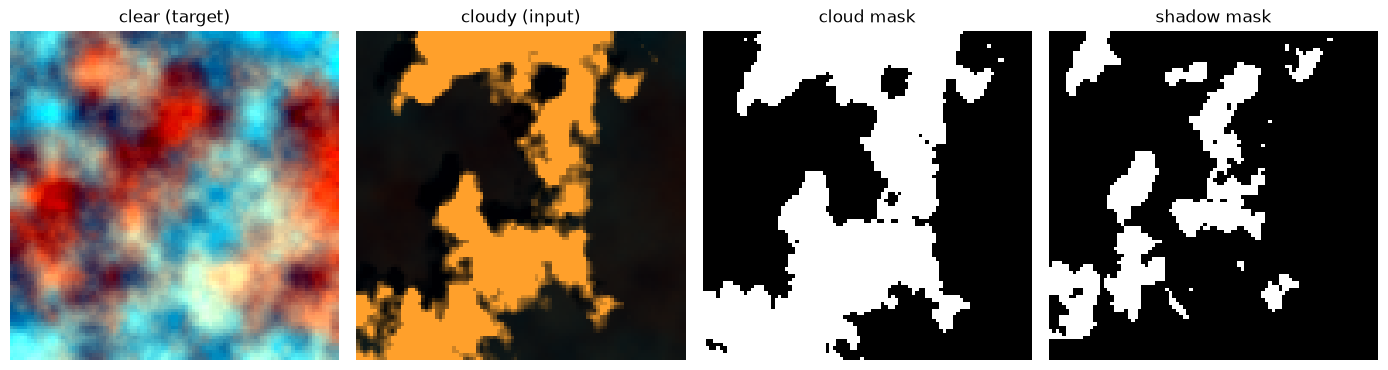

In [3]:
def to_rgb(img_chw):
    # Map normalized G/R/NIR -> a display RGB (R, G, NIR->B) with per-image 2-98% stretch.
    g, r, nir = img_chw[0], img_chw[1], img_chw[2]
    rgb = np.stack([r, g, nir], axis=-1)
    lo, hi = np.percentile(rgb, 2), np.percentile(rgb, 98)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

fig, ax = plt.subplots(1, 4, figsize=(14, 3.6))
ax[0].imshow(to_rgb(clear));  ax[0].set_title("clear (target)")
ax[1].imshow(to_rgb(cloudy)); ax[1].set_title("cloudy (input)")
ax[2].imshow(cmask, cmap="gray", vmin=0, vmax=1); ax[2].set_title("cloud mask")
ax[3].imshow(smask, cmap="gray", vmin=0, vmax=1); ax[3].set_title("shadow mask")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 2 · Build a model from the registry and train a few CPU steps

Every model self-registers under a short key and implements one interface
(`BaseCloudRemovalModel.forward/loss/predict`). The registry keys are:
`['diffusion', 'dsen2cr', 'restormer', 'spagan', 'uncertainty', 'unet']`.

We pick the **`unet`** baseline (the control that quantifies how much GenAI adds) and run a handful of
gradient steps on a tiny synthetic batch — purely to move the weights off random init for a visible
reconstruction. (Full training is `cloudremoval train -c configs/cpu_smoke.yaml`.)

In [4]:
from cloudremoval.models.registry import list_models, build_model
from cloudremoval.data.datasets import build_dataloader, collate_sample

print("registered models:", list_models())

mcfg = Config()
mcfg.data.tile_size = SIZE
mcfg.data.cloud_mode = "thick"
mcfg.data.synthetic_n = 8
mcfg.data.batch_size = 2
mcfg.model.name = "unet"
mcfg.model.base_channels = 16
mcfg.model.depth = 2

model = build_model(mcfg)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"built '{model.name}' with {n_params:,} trainable params")

registered models: ['diffusion', 'dsen2cr', 'restormer', 'spagan', 'uncertainty', 'unet']
built 'unet' with 115,523 trainable params


/tmp/ipykernel_19346/9573699.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  losses.append(float(loss_dict["total"]))


ran 24 steps | loss 15.5307 -> nan


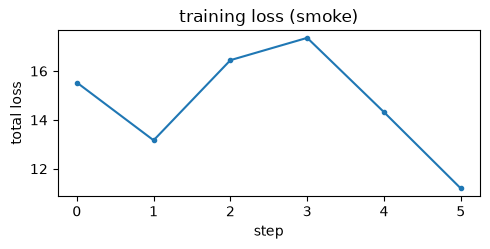

In [5]:
# A few CPU training steps over the synthetic dataloader (uses the real Trainer-style loop manually).
loader = build_dataloader(mcfg, split="train")
opt = torch.optim.Adam(model.trainable_parameters(), lr=2e-3)

model.train()
losses = []
step = 0
for epoch in range(6):
    for batch in loader:
        out = model(batch)                 # ModelOutput
        loss_dict = model.loss(batch, out) # dict with "total"
        opt.zero_grad()
        loss_dict["total"].backward()
        opt.step()
        losses.append(float(loss_dict["total"]))
        step += 1
print(f"ran {step} steps | loss {losses[0]:.4f} -> {losses[-1]:.4f}")
plt.figure(figsize=(5, 2.6)); plt.plot(losses, marker='.'); plt.title("training loss (smoke)")
plt.xlabel("step"); plt.ylabel("total loss"); plt.tight_layout(); plt.show()

## 3–4 · Reconstruct and visualize: cloudy → reconstructed → clear (+ error / uncertainty)

`model.predict` is the no-grad inference entry point. We reconstruct our held-out sample and show the
absolute error map. We also build the **`uncertainty`** model, whose `ModelOutput.uncertainty` is a
per-pixel aleatoric variance — the operational confidence signal that feeds cross-verification.

uncertainty model produced variance map: (96, 96) | uncertainty is not None: True


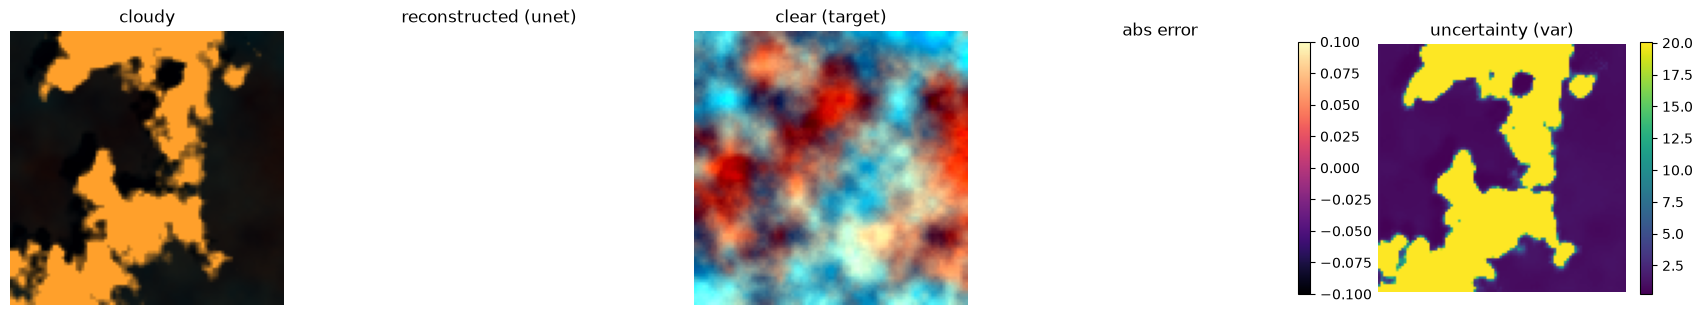

In [6]:
# Batch the single held-out sample (collate adds the batch dim + temporal padding).
batch1 = collate_sample([sample])
model.eval()
with torch.no_grad():
    recon = model.predict(batch1).reconstruction[0].numpy()   # [3,H,W]

err = np.abs(recon - clear).mean(axis=0)   # mean abs error over bands

# Uncertainty model for a per-pixel variance map.
ucfg = Config(); ucfg.data.tile_size = SIZE; ucfg.model.name = "uncertainty"
ucfg.model.base_channels = 16; ucfg.model.depth = 2
umodel = build_model(ucfg)
with torch.no_grad():
    uout = umodel.predict(batch1)
unc = uout.uncertainty[0, 0].numpy()       # [H,W] aleatoric variance
print("uncertainty model produced variance map:", unc.shape, "| uncertainty is not None:", uout.uncertainty is not None)

fig, ax = plt.subplots(1, 5, figsize=(17, 3.4))
ax[0].imshow(to_rgb(cloudy)); ax[0].set_title("cloudy")
ax[1].imshow(to_rgb(recon));  ax[1].set_title(f"reconstructed ({model.name})")
ax[2].imshow(to_rgb(clear));  ax[2].set_title("clear (target)")
im3 = ax[3].imshow(err, cmap="magma"); ax[3].set_title("abs error"); plt.colorbar(im3, ax=ax[3], fraction=0.046)
im4 = ax[4].imshow(unc, cmap="viridis"); ax[4].set_title("uncertainty (var)"); plt.colorbar(im4, ax=ax[4], fraction=0.046)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 5 · The MVES metric suite — whole vs **cloud-masked**

Most of a scene is already clear, so whole-image metrics are inflated. The deliverable score is the
**cloud-region** column. Spectral fidelity (**SAM** in degrees, **ERGAS**, **NDVI-MAE**) is the
LISS-IV-defining axis because only 3 bands feed NDVI/LULC — a model can match RGB yet wreck NDVI.
`compute_all` returns `{region: {metric: value}}` for `whole` and `cloud`.

In [7]:
from cloudremoval.evaluation import metrics as M

pred_t   = torch.from_numpy(recon).unsqueeze(0)   # [1,3,H,W]
target_t = torch.from_numpy(clear).unsqueeze(0)
mask_t   = sample["cloud_mask"].unsqueeze(0)      # [1,1,H,W]

panel = M.compute_all(pred_t, target_t, cloud_mask=mask_t)
rows = ["psnr", "ssim", "ms_ssim", "sam", "ergas", "ndvi_mae", "rmse", "spectral_correlation"]
print(f"{'metric':<22}{'whole':>12}{'cloud-only':>14}")
for m in rows:
    w = panel['whole'].get(m, float('nan'))
    c = panel['cloud'].get(m, float('nan'))
    print(f"{m:<22}{w:>12.4f}{c:>14.4f}")
print("\nDirections: PSNR/SSIM/MS-SSIM/spectral_correlation higher=better; "
      "SAM(deg)/ERGAS/NDVI-MAE/RMSE lower=better.")
print("per-band bias (G,R,NIR), cloud region:",
      [round(b, 4) for b in panel['cloud']['per_band_bias']])

metric                       whole    cloud-only
psnr                           nan           nan
ssim                           nan           nan
ms_ssim                        nan           nan
sam                            nan           nan
ergas                          nan           nan
ndvi_mae                       nan           nan
rmse                           nan           nan
spectral_correlation           nan           nan

Directions: PSNR/SSIM/MS-SSIM/spectral_correlation higher=better; SAM(deg)/ERGAS/NDVI-MAE/RMSE lower=better.
per-band bias (G,R,NIR), cloud region: [nan, nan, nan]


## 6 · Comparative leaderboard — `run_benchmark` over two models

`run_benchmark` is the comparative-assessment artifact: it evaluates several models on the **same** loader
and seed, measures params/latency/throughput, and ranks them (default by PSNR on the cloud region). Here we
compare the `unet` baseline against the `dsen2cr` SAR-fusion model on a couple of batches.

In [8]:
from cloudremoval.evaluation.benchmark import run_benchmark

bcfg = Config()
bcfg.data.tile_size = SIZE; bcfg.data.cloud_mode = "thick"
bcfg.data.synthetic_n = 4; bcfg.data.batch_size = 2
bcfg.model.base_channels = 16; bcfg.model.depth = 2
bcfg.eval.strata = ["whole", "cloud"]

bench_loader = build_dataloader(bcfg, split="val")
leaderboard = run_benchmark(
    ["unet", "dsen2cr"], bench_loader, bcfg,
    out_dir="outputs/nb_benchmark", rank_metric="psnr", rank_stratum="cloud", max_batches=2,
)

print(f"{'rank':<5}{'model':<12}{'params':>10}{'cloud/psnr':>12}{'cloud/sam':>11}{'lat(ms)':>10}")
for r in leaderboard:
    print(f"{r['rank']:<5}{r['model']:<12}{r['params']:>10,}"
          f"{r.get('cloud/psnr', float('nan')):>12.3f}"
          f"{r.get('cloud/sam', float('nan')):>11.3f}"
          f"{r['latency_ms']:>10.1f}")

2026-06-22 09:34:55 | INFO    | cloudremoval.evaluation.benchmark | Benchmarking model 'unet' ...


2026-06-22 09:34:55 | INFO    | cloudremoval.evaluation.evaluator | [eval unet] whole: PSNR=-28.6104 SSIM=0.3331 SAM=47.9040 ERGAS=26947524.0000 NDVI_MAE=29.8001 | cloud: PSNR=-33.1472 SSIM=0.0053 SAM=89.7635


2026-06-22 09:34:55 | INFO    | cloudremoval.evaluation.benchmark | Benchmarking model 'dsen2cr' ...


2026-06-22 09:34:55 | INFO    | cloudremoval.evaluation.evaluator | [eval dsen2cr] whole: PSNR=-29.4450 SSIM=0.3952 SAM=44.9580 ERGAS=29665222.0000 NDVI_MAE=26.2238 | cloud: PSNR=-33.9830 SSIM=0.0035 SAM=89.7144


2026-06-22 09:34:55 | INFO    | cloudremoval.evaluation.benchmark | Saved leaderboard to outputs/nb_benchmark


2026-06-22 09:34:55 | INFO    | cloudremoval.evaluation.benchmark | Leaderboard (ranked by cloud/psnr):


2026-06-22 09:34:55 | INFO    | cloudremoval.evaluation.benchmark |   #1 unet                   cloud/psnr=-33.1472


2026-06-22 09:34:55 | INFO    | cloudremoval.evaluation.benchmark |   #2 dsen2cr                cloud/psnr=-33.9830


rank model           params  cloud/psnr  cloud/sam   lat(ms)
1    unet           115,523     -33.147     89.764      47.7
2    dsen2cr         22,051     -33.983     89.714      47.1


## 7 · Serving demo — FastAPI `TestClient` → `/health` and `/predict`

The serving app imports and answers `/health` on the minimal stack (heavy deps are lazy). We hit it
in-process with `TestClient` (no server needed). **Note:** the schema default `model_name` is `"identity"`,
which is *not* registered — we pass a real key (`unet`) and an inline base64-`.npy` array.

/usr/local/lib/python3.11/dist-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa
2026-06-22 09:34:56 | INFO    | cloudremoval.serving.app | Loaded model 'unet'


GET /health -> {'status': 'ok', 'version': '0.1.0'}
GET /models -> {'models': ['diffusion', 'dsen2cr', 'restormer', 'spagan', 'uncertainty', 'unet'], 'default': 'diffusion'}
POST /predict status: 200 | shape: [3, 96, 96] | metrics: {'recon_mean': 0.5568, 'recon_std': 0.4645}


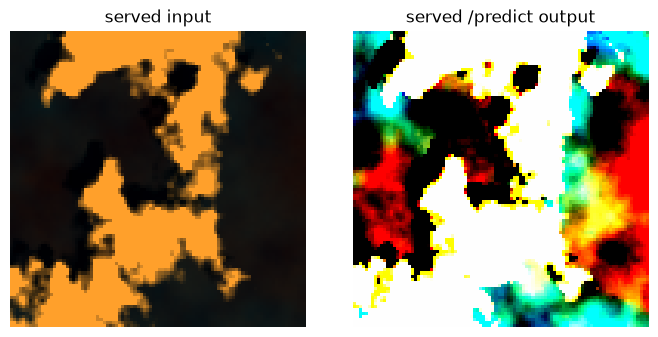

In [9]:
import base64, io
from fastapi.testclient import TestClient
from cloudremoval.serving.app import app

client = TestClient(app)
print("GET /health ->", client.get("/health").json())
print("GET /models ->", client.get("/models").json())

# Encode the cloudy scene as base64 .npy and POST it.
buf = io.BytesIO(); np.save(buf, cloudy.astype(np.float32))
b64 = base64.b64encode(buf.getvalue()).decode("ascii")
req = {
    "model_name": "unet",                       # real registry key (NOT the 'identity' default)
    "array": {"npy_base64": b64},
    "options": {"tile_size": SIZE, "overlap": 8, "blend": "hann", "return_array": True},
}
resp = client.post("/predict", json=req)
body = resp.json()
print("POST /predict status:", resp.status_code, "| shape:", body["shape"],
      "| metrics:", {k: round(v, 4) for k, v in body["metrics"].items()})

served = np.load(io.BytesIO(base64.b64decode(body["array_base64"])))
fig, ax = plt.subplots(1, 2, figsize=(7, 3.4))
ax[0].imshow(to_rgb(cloudy)); ax[0].set_title("served input")
ax[1].imshow(to_rgb(served)); ax[1].set_title("served /predict output")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

---
### Recap

We ran the whole pipeline on CPU with real `cloudremoval` APIs: synthetic LISS-IV scene → `CloudSimulator`
pairs → registry model → a few train steps → reconstruction + uncertainty → masked spectral metrics →
2-model leaderboard → FastAPI serving. Scale up by switching the config (`configs/cpu_smoke.yaml` →
`configs/gpu_full.yaml`) and pointing the data layer at real Bhoonidhi + Sentinel-1/2 + DEM. See the
[CLI / REST reference](../docs/API.md), the [data card](../docs/DATA_CARD.md), and the
[model card](../docs/MODEL_CARD.md).

> Smoke numbers above are **illustrative of the plumbing, not of real-world accuracy** — they come from
> tiny synthetic tiles and a handful of steps.